# Tech Challenge - Fase 5: LSTM Training Report

Este notebook é **somente leitura** — ele consome runs do **MLflow Tracking** e produz a narrativa analítica usada no Demo Day. Todo treino acontece em [`src/ibov_pipeline/train_lstm.py`](../src/ibov_pipeline/train_lstm.py) (estágio `train_lstm` do DVC); aqui apenas lemos o tracking server, montamos comparativos e justificamos a escolha do *champion*.

Por que essa separação?

- **GAP 02** do guia (notebook como SPOF): pipelines de produção não devem depender de execução manual de notebook.
- **Nível 2 do Microsoft MLOps Maturity Model**: "MLflow padronizado, comparação sistemática auditável". Cada combinação de hiperparâmetros é um *child run* do MLflow — auditável via UI, não via prints aqui.
- **Demo Day**: o notebook é o entregável narrativo ("por que escolhemos esses hiperparâmetros?"); o `.py` é a evidência de pipeline reprodutível.

**Pré-requisito**: ter executado pelo menos uma vez:

```bash
python -m src.ibov_pipeline.train_lstm
```

## 0. Bootstrap

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault(
    "MODEL_CONFIG_PATH",
    str(PROJECT_ROOT / "src" / "ibov_pipeline" / "configs"/"model_config.yaml"),
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient

from src.ibov_pipeline.config import cfg

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(f"Tracking URI    : {cfg.mlflow.tracking_uri}")
print(f"Experiment name : {cfg.mlflow.experiment_name}")

Tracking URI    : /Users/alan/Data Science Projects/datathon-techchallenge-fase-5/mlruns
Experiment name : ibov-forecasting


## 1. Conexão com o MLflow Tracking

In [2]:
mlflow.set_tracking_uri(cfg.mlflow.tracking_uri)
client = MlflowClient()

experiment = client.get_experiment_by_name(cfg.mlflow.experiment_name)
if experiment is None:
    raise RuntimeError(
        f"Experimento '{cfg.mlflow.experiment_name}' não existe. "
        "Rode `python -m src.ibov_pipeline.train_lstm` antes deste notebook."
    )

print(f"Experiment id   : {experiment.experiment_id}")
print(f"Lifecycle stage : {experiment.lifecycle_stage}")
print(f"Artifact root   : {experiment.artifact_location}")

Experiment id   : 554679550644520559
Lifecycle stage : active
Artifact root   : /Users/alan/Data Science Projects/datathon-techchallenge-fase-5/mlruns/554679550644520559


/Users/alan/Data Science Projects/datathon-techchallenge-fase-5/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 2. Localizando a busca de hiperparâmetros mais recente

O run **pai** da busca é identificado pela tag `pipeline_stage = 'hparam-search'`. Ele agrupa todos os trials como *child runs* (tag `pipeline_stage = 'hparam-trial'`).

In [3]:
# Tenta primeiro o modo SEARCH (grid search com nested runs).
# Se não houver, cai para SINGLE-RUN (último treino LSTM avulso).
search_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.pipeline_stage = 'hparam-search'",
    order_by=["attributes.start_time DESC"],
    max_results=1,
)

if search_runs:
    parent = search_runs[0]
    is_search_mode = True
    print("Modo: GRID SEARCH (nested runs)\n")
else:
    single_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.pipeline_stage = 'lstm'",
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    if not single_runs:
        raise RuntimeError(
            "Nenhum treino LSTM encontrado. "
            "Rode `python -m src.ibov_pipeline.train_lstm` antes deste notebook."
        )
    parent = single_runs[0]
    is_search_mode = False
    print("Modo: SINGLE RUN (sem grid search)")
    print("Para a comparação completa de trials, habilite `tuner.enabled: true` "
          "em model_config.yaml e re-execute o treino.\n")

start = pd.to_datetime(parent.info.start_time, unit="ms")
print(f"parent_run_id  : {parent.info.run_id}")
print(f"started_at     : {start}")
if is_search_mode:
    print(f"n_trials       : {parent.data.params.get('n_trials')}")
    print(f"search_type    : {parent.data.tags.get('search_type')}")
print(f"git_sha        : {parent.data.tags.get('git_sha')}")
print(f"dataset_hash   : {parent.data.tags.get('dataset_hash')}")
print(f"best_run_id    : {parent.data.tags.get('best_run_id') or parent.info.run_id}")

Modo: GRID SEARCH (nested runs)

parent_run_id  : 75149911374841469ef423d1de5041db
started_at     : 2026-05-01 20:24:55.875000
n_trials       : 10
search_type    : grid
git_sha        : 69b978a06ffb25e77c788b250e3909bc3bd95c18
dataset_hash   : 1500fa61dc6a
best_run_id    : e25d63af342446a798c1cb668750bdb0


## 3. Tabela comparativa de todos os trials

Carregamos os runs filhos da busca e organizamos numa única tabela ordenada pelo MAPE no test set. Cada linha é um run MLflow auditável independentemente.

In [4]:
if is_search_mode:
    trials = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=f"tags.parent_run_id = '{parent.info.run_id}'",
        order_by=["metrics.mape ASC"],
    )
else:
    # Single-run: a 'lista' de trials é só o próprio run
    trials = [parent]

def _row(r):
    p, m, t = r.data.params, r.data.metrics, r.data.tags
    return {
        "trial": int(t.get("trial_index", 0)) if t.get("trial_index") else 0,
        "units_1": int(p["units_1"]),
        "units_2": int(p["units_2"]),
        "dropout_1": float(p["dropout_1"]),
        "dropout_2": float(p["dropout_2"]),
        "learning_rate": float(p["learning_rate"]),
        "epochs_trained": int(p.get("epochs_trained", 0)),
        "mape_test_%": m.get("mape", float("nan")) * 100,
        "mae_test": m.get("mae"),
        "rmse_test": m.get("rmse"),
        "dir_acc_%": m.get("directional_accuracy", float("nan")) * 100,
        "mape_holdout_%": m.get("holdout_mape", float("nan")) * 100,
        "mae_holdout": m.get("holdout_mae"),
        "run_id": r.info.run_id[:8],
    }

df = pd.DataFrame([_row(r) for r in trials]).sort_values("mape_test_%").reset_index(drop=True)
df.head(15)

,trial,units_1,units_2,dropout_1,dropout_2,learning_rate,epochs_trained,mape_test_%,mae_test,rmse_test,dir_acc_%,mape_holdout_%,mae_holdout,run_id
0,5,96,32,0.1000,0.1000,0.0100,71,0.7013,909.0675,"1,196.5590",53.6278,1.2314,"2,099.9040",e25d63af
1,0,32,32,0.1000,0.1000,0.0100,69,0.7075,915.5255,"1,205.9956",52.6814,0.9219,"1,558.2328",29c013c7
2,2,32,128,0.2000,0.1000,0.0100,74,0.7181,931.9458,"1,226.9584",56.1514,1.2445,"2,114.9228",18d422b5
3,6,96,64,0.4000,0.1000,0.0100,83,0.7284,943.4527,"1,237.2053",51.7350,0.9709,"1,637.1321",6aa7ad00
4,7,96,128,0.2000,0.1000,0.0100,81,0.7355,950.9250,"1,245.6430",52.0505,0.8995,"1,516.9005",4524f632
5,1,32,64,0.4000,0.1000,0.0100,53,0.7651,992.0035,"1,280.5157",52.9968,1.1958,"2,025.9921",fedf3030
6,3,64,32,0.5000,0.1000,0.0100,80,0.7658,991.7634,"1,278.9752",52.6814,1.3966,"2,391.0802",f6121b53
7,4,64,96,0.3000,0.1000,0.0100,56,0.7921,"1,028.6598","1,322.5389",52.0505,1.1905,"2,008.0484",bd248fac
8,9,128,96,0.3000,0.1000,0.0100,44,0.8310,"1,076.4346","1,374.9508",52.6814,1.2363,"2,093.7058",6950aaa7
9,8,128,32,0.5000,0.1000,0.0100,29,1.0744,"1,401.3661","1,799.4914",51.7350,2.1792,"3,701.7141",17cac15c


## 4. Visualização da busca

Três cortes que respondem perguntas distintas:

1. **MAPE por `learning_rate`** — qual ordem de grandeza de LR funciona melhor.
2. **MAPE por capacidade (`units_1`)** — redes maiores ajudam ou apenas overfittam?
3. **Test vs. Holdout** — pontos próximos à diagonal indicam ausência de overfitting ao split de teste.

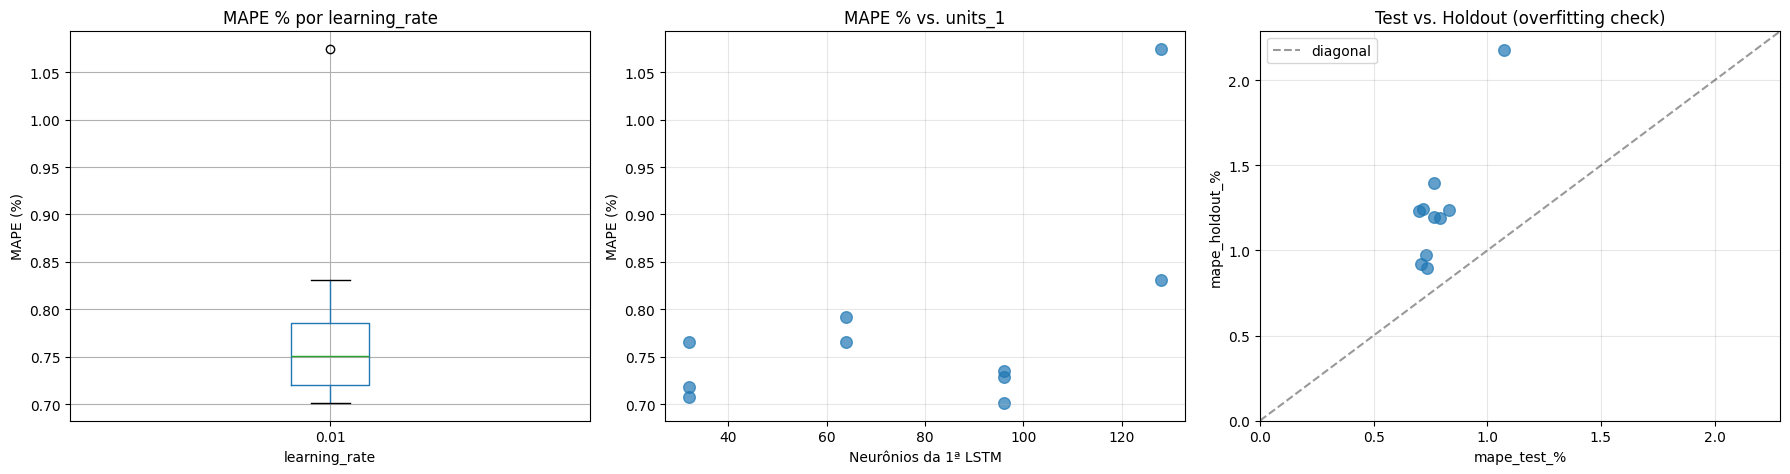

In [5]:
if len(df) <= 1:
    print("Visualização da busca pulada — apenas 1 trial disponível.")
    print("Habilite `tuner.enabled: true` em model_config.yaml para gerar comparativo entre trials.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    df.boxplot(column="mape_test_%", by="learning_rate", ax=axes[0])
    axes[0].set_title("MAPE % por learning_rate")
    axes[0].set_ylabel("MAPE (%)")
    axes[0].set_xlabel("learning_rate")

    df.plot.scatter(x="units_1", y="mape_test_%", ax=axes[1], s=70, alpha=0.7)
    axes[1].set_title("MAPE % vs. units_1")
    axes[1].set_xlabel("Neurônios da 1ª LSTM")
    axes[1].set_ylabel("MAPE (%)")
    axes[1].grid(alpha=0.3)

    if df["mape_holdout_%"].notna().any():
        df.plot.scatter(x="mape_test_%", y="mape_holdout_%", ax=axes[2], s=70, alpha=0.7)
        lim = float(np.nanmax([df["mape_test_%"].max(), df["mape_holdout_%"].max()])) * 1.05
        axes[2].plot([0, lim], [0, lim], "k--", alpha=0.4, label="diagonal")
        axes[2].set_xlim(0, lim)
        axes[2].set_ylim(0, lim)
        axes[2].legend()
        axes[2].set_title("Test vs. Holdout (overfitting check)")
        axes[2].grid(alpha=0.3)
    else:
        axes[2].set_title("Holdout não avaliado")
        axes[2].text(0.5, 0.5, "Sem métricas holdout_*", ha="center", va="center", transform=axes[2].transAxes)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 5. Champion: detalhes do run vencedor

O run filho com menor MAPE no test set é marcado pelo run pai via `tags.best_run_id`. Carregamos diretamente esse run para inspecionar todos os campos logados.

In [6]:
# Em search mode → tag 'best_run_id' aponta para o trial vencedor.
# Em single mode → o próprio parent é o champion.
best_run_id = parent.data.tags.get("best_run_id") or parent.info.run_id
champion = client.get_run(best_run_id)

print(f"Champion run_id : {best_run_id}")
print("\nHiperparâmetros:")
for k in ["units_1", "units_2", "dropout_1", "dropout_2", "learning_rate", "epochs_trained"]:
    print(f"  - {k:16s}: {champion.data.params.get(k)}")

print("\nMétricas no test set (escala real, pontos do IBOV):")
print(f"  - MAE     : {champion.data.metrics['mae']:>10,.2f} pts")
print(f"  - RMSE    : {champion.data.metrics['rmse']:>10,.2f} pts")
print(f"  - MAPE    : {champion.data.metrics['mape'] * 100:>10.2f}%")
print(f"  - Dir.Acc : {champion.data.metrics['directional_accuracy'] * 100:>10.2f}%")

if "holdout_mape" in champion.data.metrics:
    print("\nMétricas no holdout imutável:")
    print(f"  - MAE     : {champion.data.metrics['holdout_mae']:>10,.2f} pts")
    print(f"  - RMSE    : {champion.data.metrics['holdout_rmse']:>10,.2f} pts")
    print(f"  - MAPE    : {champion.data.metrics['holdout_mape'] * 100:>10.2f}%")
    print(f"  - Dir.Acc : {champion.data.metrics['holdout_directional_accuracy'] * 100:>10.2f}%")

Champion run_id : e25d63af342446a798c1cb668750bdb0

Hiperparâmetros:
  - units_1         : 96
  - units_2         : 32
  - dropout_1       : 0.1
  - dropout_2       : 0.1
  - learning_rate   : 0.01
  - epochs_trained  : 71

Métricas no test set (escala real, pontos do IBOV):
  - MAE     :     909.07 pts
  - RMSE    :   1,196.56 pts
  - MAPE    :       0.70%
  - Dir.Acc :      53.63%

Métricas no holdout imutável:
  - MAE     :   2,099.90 pts
  - RMSE    :   2,683.98 pts
  - MAPE    :       1.23%
  - Dir.Acc :      41.48%


## 6. Champion LSTM vs. Baselines Scikit-Learn

O baseline existe para responder uma pergunta dura: **o LSTM justifica sua complexidade**? Comparamos o champion contra os runs de [`train_baseline.py`](../src/ibov_pipeline/train_baseline.py) (`pipeline_stage = 'baseline'`) treinados sobre o **mesmo `dataset_hash`** — garantia de comparação justa, sem variação de dados entre os modelos.

Critério de aprovação: o champion LSTM deve superar o melhor baseline em **pelo menos 0.5 pp de MAPE no holdout** (ver `cfg.retrain.promotion_delta_mape`). Se o ganho for menor, a complexidade extra do LSTM não se paga e o baseline é a escolha racional para produção.

In [7]:
champion_dataset_hash = champion.data.tags.get("dataset_hash", "")

baseline_filter = (
    "tags.pipeline_stage = 'baseline'"
    + (f" and tags.dataset_hash = '{champion_dataset_hash}'" if champion_dataset_hash else "")
)
baseline_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=baseline_filter,
    order_by=["metrics.holdout_mape ASC"],
)

if not baseline_runs:
    print("Nenhum baseline encontrado com o mesmo dataset_hash do champion.\n"
          "Rode `python -m src.ibov_pipeline.train_baseline` para gerar a comparação.")
    comparison = None
else:
    rows = []
    for r in baseline_runs:
        m, t = r.data.metrics, r.data.tags
        rows.append({
            "model": t.get("baseline_name", r.info.run_name),
            "framework": t.get("framework", "sklearn"),
            "mape_test_%": m.get("mape", float("nan")) * 100,
            "mape_holdout_%": m.get("holdout_mape", float("nan")) * 100,
            "mae_holdout": m.get("holdout_mae"),
            "dir_acc_holdout_%": m.get("holdout_directional_accuracy", float("nan")) * 100,
            "run_id": r.info.run_id[:8],
        })
    # Adiciona o champion LSTM na mesma tabela
    cm = champion.data.metrics
    rows.append({
        "model": "LSTM (champion)",
        "framework": "tensorflow-keras",
        "mape_test_%": cm.get("mape", float("nan")) * 100,
        "mape_holdout_%": cm.get("holdout_mape", float("nan")) * 100,
        "mae_holdout": cm.get("holdout_mae"),
        "dir_acc_holdout_%": cm.get("holdout_directional_accuracy", float("nan")) * 100,
        "run_id": best_run_id[:8],
    })
    comparison = pd.DataFrame(rows).sort_values("mape_holdout_%").reset_index(drop=True)

comparison

,model,framework,mape_test_%,mape_holdout_%,mae_holdout,dir_acc_holdout_%,run_id
0,LinearRegression,scikit-learn,0.7194,0.8967,"1,503.2937",45.4545,1aeb2860
1,LinearRegression,scikit-learn,0.7188,0.9039,"1,518.3558",45.4545,52af1502
2,LSTM (champion),tensorflow-keras,0.7013,1.2314,"2,099.9040",41.4773,e25d63af
3,Ridge,scikit-learn,0.9889,1.6723,"2,816.0110",45.4545,63c84a5b
4,Ridge,scikit-learn,0.9888,1.6734,"2,815.1996",45.4545,74ea081d
5,RandomForest,scikit-learn,2.0524,19.3907,"33,539.2973",41.4773,021d8f67
6,RandomForest,scikit-learn,2.0604,19.5364,"33,825.4234",40.9091,b761376a


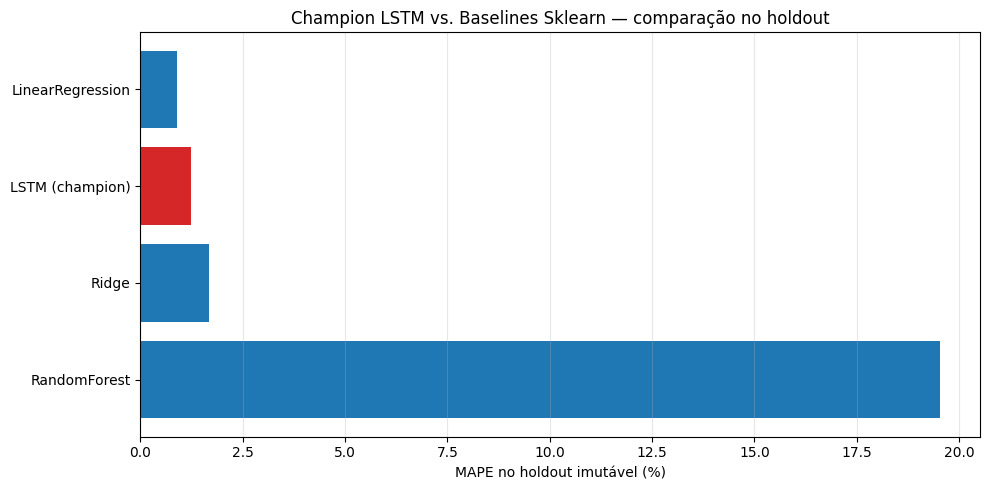

Melhor baseline       : LinearRegression (MAPE holdout = 0.8967%)
Champion LSTM         : MAPE holdout = 1.2314%
Δ a favor do LSTM     : -0.3347 pp
Threshold de promoção : 0.5000 pp (cfg.retrain.promotion_delta_mape)
Veredito              : ⚠️ NÃO JUSTIFICADO


In [8]:
if comparison is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#d62728" if m == "LSTM (champion)" else "#1f77b4" for m in comparison["model"]]
    ax.barh(comparison["model"], comparison["mape_holdout_%"], color=colors)
    ax.set_xlabel("MAPE no holdout imutável (%)")
    ax.set_title("Champion LSTM vs. Baselines Sklearn — comparação no holdout")
    ax.invert_yaxis()  # melhor (menor MAPE) no topo
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    best_baseline = comparison[comparison["model"] != "LSTM (champion)"].iloc[0]
    champion_row = comparison[comparison["model"] == "LSTM (champion)"].iloc[0]
    delta_pp = best_baseline["mape_holdout_%"] - champion_row["mape_holdout_%"]
    threshold_pp = cfg.retrain.promotion_delta_mape * 100

    verdict = "✅ JUSTIFICADO" if delta_pp >= threshold_pp else "⚠️ NÃO JUSTIFICADO"
    print(f"Melhor baseline       : {best_baseline['model']} (MAPE holdout = {best_baseline['mape_holdout_%']:.4f}%)")
    print(f"Champion LSTM         : MAPE holdout = {champion_row['mape_holdout_%']:.4f}%")
    print(f"Δ a favor do LSTM     : {delta_pp:+.4f} pp")
    print(f"Threshold de promoção : {threshold_pp:.4f} pp (cfg.retrain.promotion_delta_mape)")
    print(f"Veredito              : {verdict}")

## 7. Lineage e governança (Nível 2 / GAP 05)

A banca avalia se cada run tem metadata mínima de auditoria. Listamos as tags exigidas pelo guia do Datathon.

In [9]:
REQUIRED_TAGS = [
    "git_sha",
    "dataset_hash",
    "training_data_version",
    "model_version",
    "model_type",
    "framework",
    "owner",
    "phase",
    "risk_level",
    "fairness_checked",
]

tag_status = pd.DataFrame([
    {"tag": t, "value": champion.data.tags.get(t, "<ausente>")}
    for t in REQUIRED_TAGS
])
tag_status["ok"] = tag_status["value"] != "<ausente>"
tag_status

,tag,value,ok
0,git_sha,69b978a06ffb25e77c788b250e3909bc3bd95c18,True
1,dataset_hash,1500fa61dc6a,True
2,training_data_version,1500fa61dc6a,True
3,model_version,0.1.0,True
4,model_type,regression,True
5,framework,tensorflow-keras,True
6,owner,grupo-xx,True
7,phase,datathon-fase05,True
8,risk_level,medium,True
9,fairness_checked,false,True


## 8. Reconstrução visual da previsão (champion vs. holdout)

Recarregamos o artefato do champion e plotamos contra o holdout imutável — o conjunto que **nunca** foi tocado durante experimentação.

2026-05-01 17:59:48.743387: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


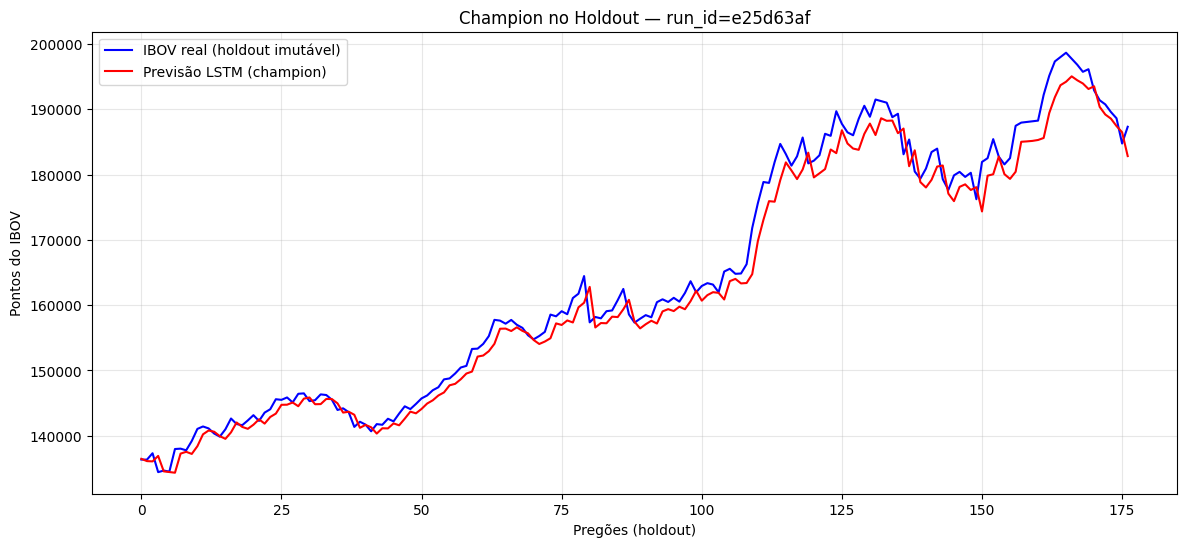

In [10]:
import joblib
from tensorflow.keras.models import load_model

model_uri = f"runs:/{best_run_id}/keras_model"
try:
    model = mlflow.keras.load_model(model_uri)
except Exception:
    # Fallback para o artefato local persistido pelo train_lstm.py
    model_path = Path(cfg.data.processed_x_path).parent / "model_lstm.keras"
    model = load_model(model_path)

scaler = joblib.load(cfg.data.scaler_path)
X_hold = np.load(cfg.data.holdout_x_path)
y_hold = np.load(cfg.data.holdout_y_path)

y_pred_real = scaler.inverse_transform(model.predict(X_hold, verbose=0)).flatten()
y_real = scaler.inverse_transform(y_hold.reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 6))
plt.plot(y_real, color="blue", label="IBOV real (holdout imutável)")
plt.plot(y_pred_real, color="red", label="Previsão LSTM (champion)")
plt.title(f"Champion no Holdout — run_id={best_run_id[:8]}")
plt.xlabel("Pregões (holdout)")
plt.ylabel("Pontos do IBOV")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Narrativa da decisão

O champion foi selecionado por três critérios, em ordem:

1. **Menor MAPE no test set** (critério primário, configurado em `optimization_metric` do run pai).
2. **MAPE no holdout próximo do MAPE no test** — confirma que não há overfitting ao split de teste (gráfico §4 deve mostrar pontos próximos à diagonal).
3. **Simplicidade arquitetural como desempate** — quando trials empatam (ΔMAPE < 0.05 pp), preferimos menor `units_1 × units_2` para reduzir latência da API de serving.

A **acurácia direcional ≈ 50%** é esperada e está documentada em [`docs/MODEL_CARD_IBOV.md`](../docs/MODEL_CARD_IBOV.md): o LSTM univariado, ao otimizar MSE, converge para uma estratégia conservadora ("amanhã ≈ hoje") — boa para magnitude, ruim para direção. Por isso o modelo é exposto pelo agente como **filtro de viés direcional**, não como sinal de trading autônomo.

## 10. Próximos passos

| Passo | Comando | Responsável no projeto |
|---|---|---|
| Promover champion para o **MLflow Model Registry** (`Staging`) com tags obrigatórias | `python -m src.ibov_pipeline.register_model --run-id <best_run_id>` | [`register_model.py`](../src/ibov_pipeline/register_model.py) |
| Comparar com baseline Sklearn no mesmo experimento | `python -m src.ibov_pipeline.train_baseline` | [`train_baseline.py`](../src/ibov_pipeline/train_baseline.py) |
| Avaliação **champion-challenger** programada | `python -m src.ibov_pipeline.retrain` | [`retrain.py`](../src/ibov_pipeline/retrain.py) |
| **PSI / drift** dispara retraining quando `> 0.20` | (cron) | [`monitoring/drift_detection.py`](../src/monitoring/drift_detection.py) |

Print final do comando pronto para copiar:

In [11]:
print(f"python -m src.ibov_pipeline.register_model --run-id {best_run_id}")

python -m src.ibov_pipeline.register_model --run-id e25d63af342446a798c1cb668750bdb0
